Searching for nnU-Net predictions...
  Found: /NAS/mmaiurov/datasets_benchmark/human_neurons_dodt/results/nnunet_3d_fullres_DEFAULT
  4 prediction files
  Test files: ['2025-10-17_11-52-37.tif', '2025-10-17_11-59-37.tif', '2025-10-17_12-00-30.tif', '2025-10-17_19-58-45.tif']

Searching for best slice...

  Best: 2025-10-17_11-52-37.tif z=0, score=209, GT={'clean': 3, 'merged': 1, 'underseg': 1, 'missed': 2}, Pred={'spurious': 3, 'clean': 3, 'underseg': 1}
  Best: 2025-10-17_11-52-37.tif z=3, score=234, GT={'merged': 2, 'clean': 3, 'missed': 1, 'underseg': 1}, Pred={'spurious': 2, 'clean': 3, 'overseg': 1, 'underseg': 1}

Selected: 2025-10-17_11-52-37.tif z=3
  GT:   {'merged': 2, 'clean': 3, 'missed': 1, 'underseg': 1}
  Pred: {'spurious': 2, 'clean': 3, 'overseg': 1, 'underseg': 1}


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

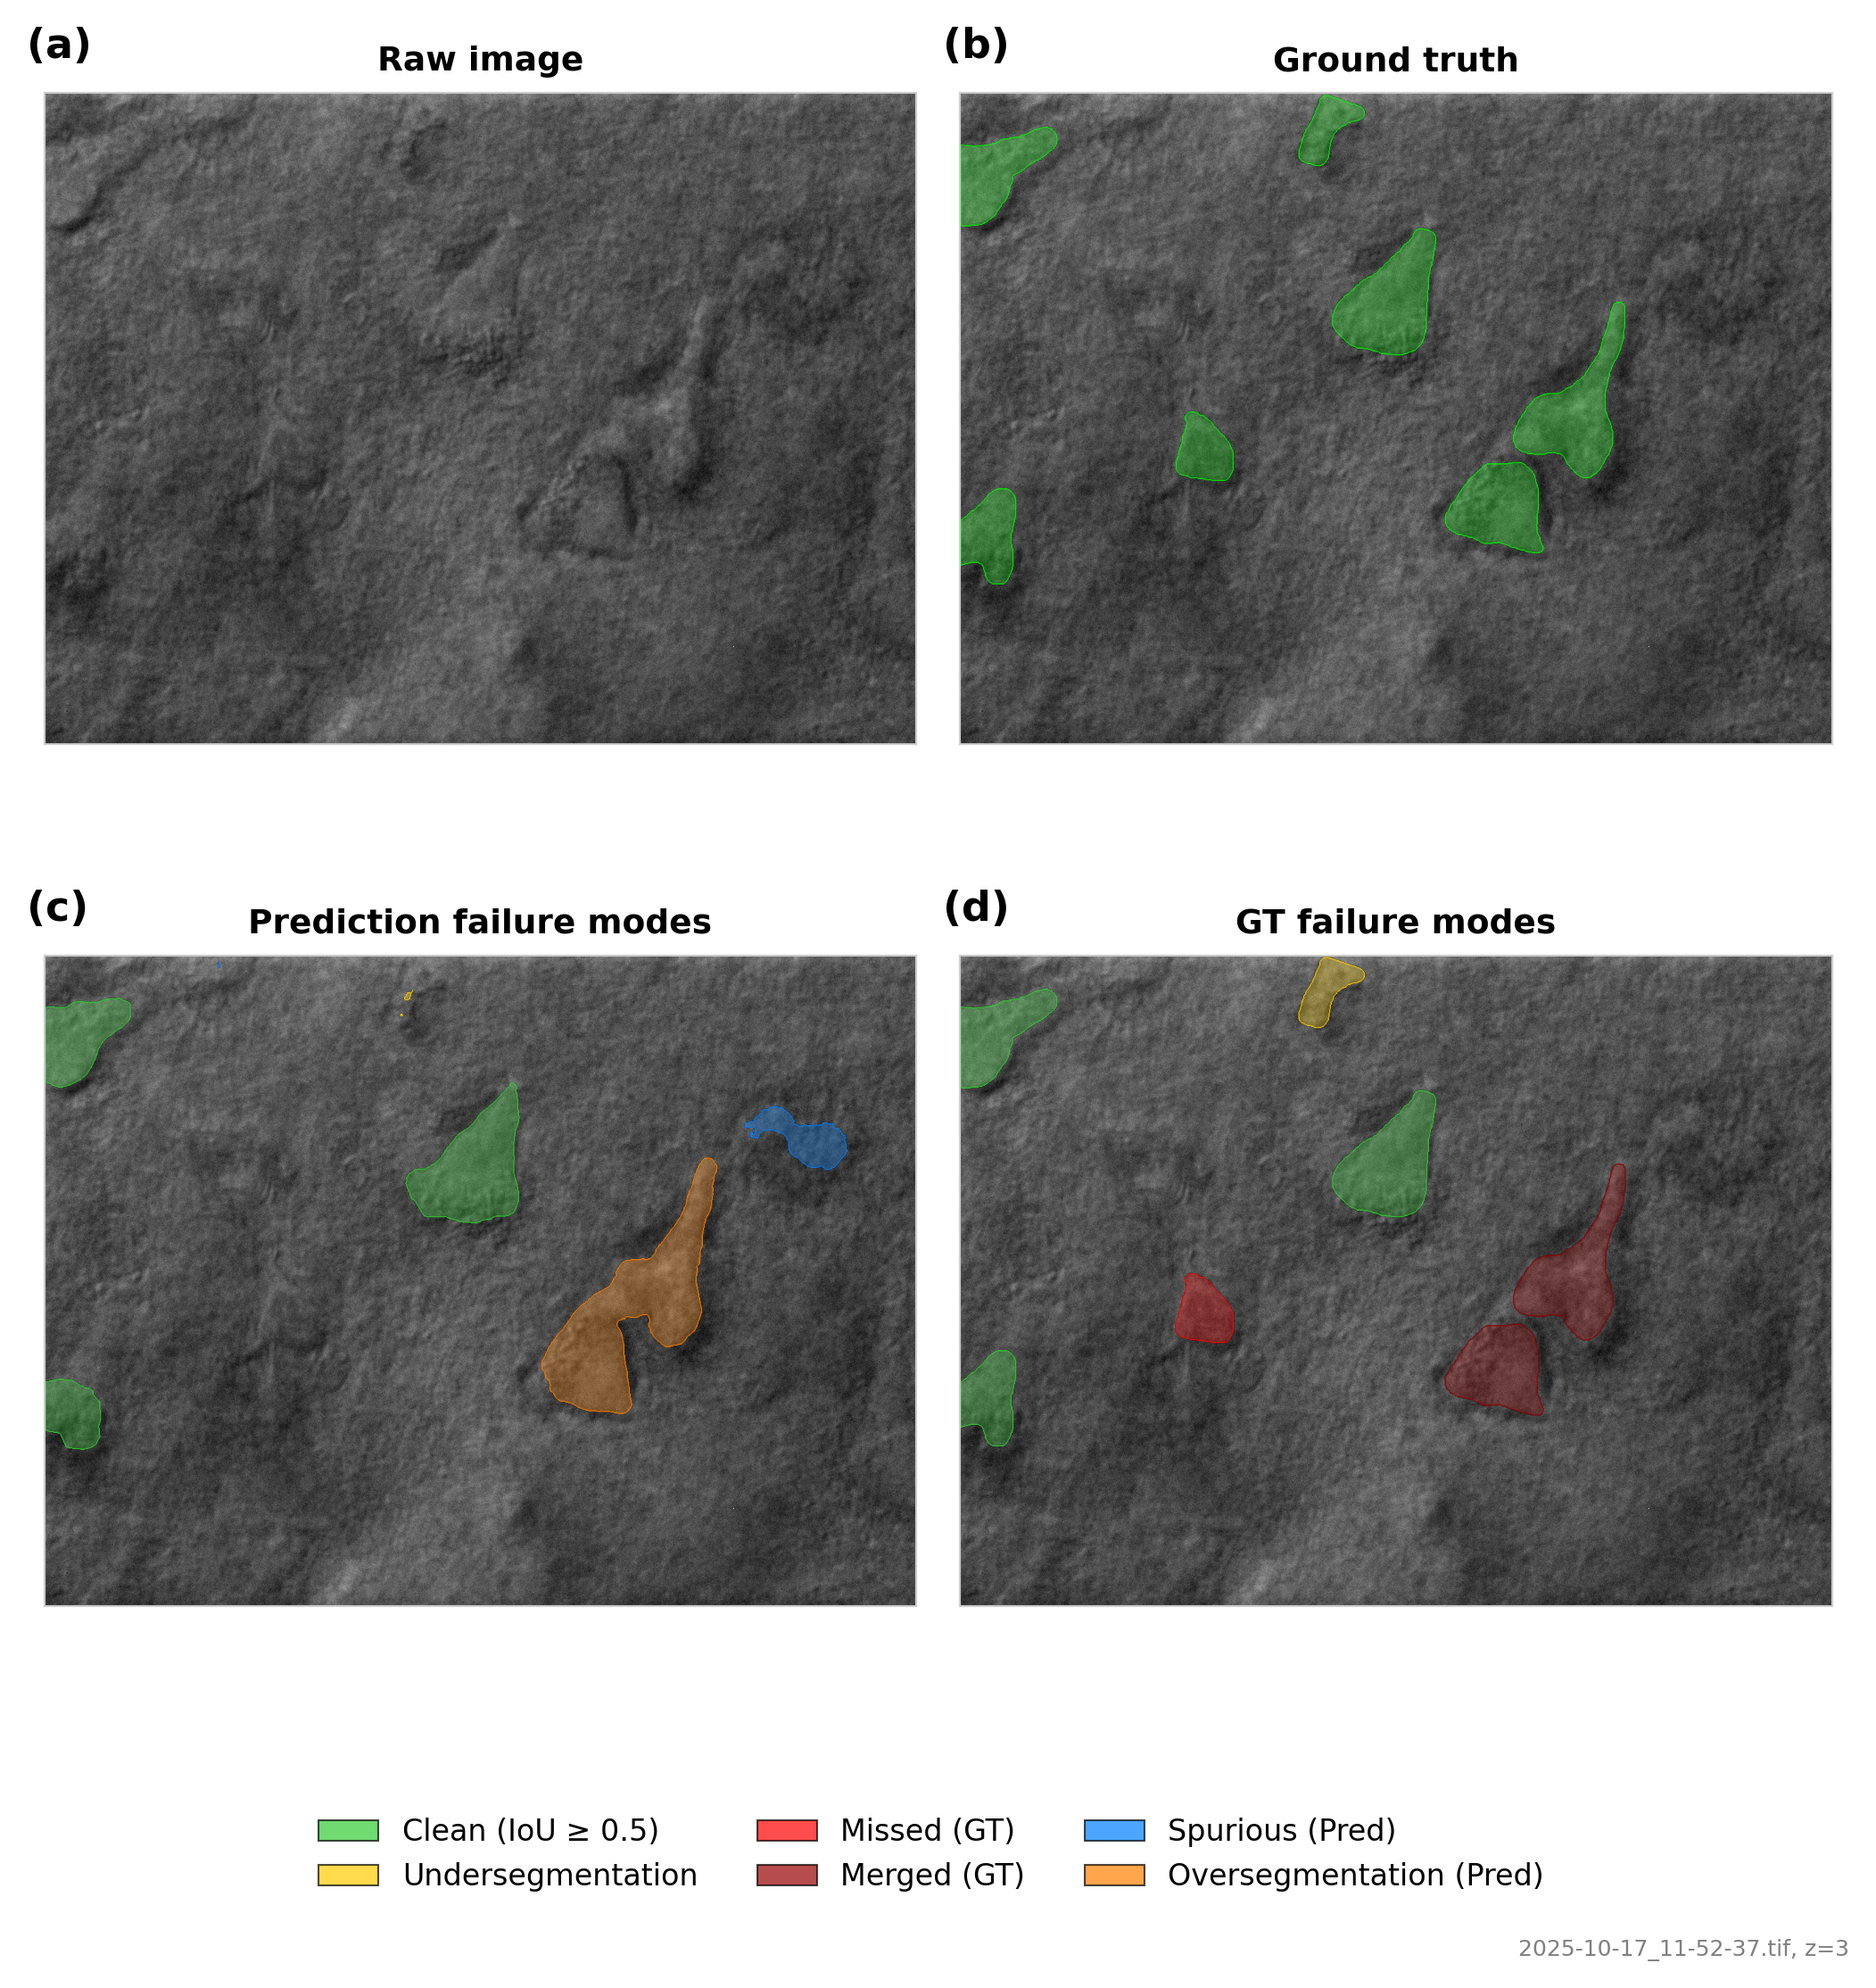


Saved: fig_failure_modes_visual.pdf / .png


In [7]:
"""
fig_failure_modes_visual.py — Qualitative failure mode visualization for MIA.

2x2 layout:
  (a) Raw image              (b) Ground truth overlay
  (c) Pred failure modes     (d) GT failure modes

Requires slice with spurious predictions for completeness.

Usage:
    python fig_failure_modes_visual.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from pathlib import Path
from tifffile import imread
from scipy.ndimage import binary_erosion
from collections import Counter
import json

# ═══════════════════════════════════════════════════════════════════════════
#  CONFIG
# ═══════════════════════════════════════════════════════════════════════════

BASE = Path("/NAS/mmaiurov/datasets_benchmark")

DATASET = "human_neurons_dodt"
IMAGE_DIR = BASE / DATASET / "images"
MASK_DIR  = BASE / DATASET / "masks"
PRED_DIR  = BASE / DATASET / "results"
SPLIT_PATH = BASE / DATASET / "split.json"

IOU_THRESHOLD = 0.5

# ═══════════════════════════════════════════════════════════════════════════
#  FIND PREDICTION FILES
# ═══════════════════════════════════════════════════════════════════════════

def find_pred_dir(base_pred_dir):
    """Search for nnU-Net prediction directory."""
    if not base_pred_dir.exists():
        return None
    for d in sorted(base_pred_dir.rglob("*")):
        if d.is_dir() and "nnunet" in d.name.lower():
            if list(d.glob("*.tif")):
                return d
    # Check base dir itself
    if list(base_pred_dir.glob("*.tif")):
        return base_pred_dir
    return None

print("Searching for nnU-Net predictions...")
pred_dir = find_pred_dir(PRED_DIR)

# Try alternative paths
if pred_dir is None:
    for alt in [
        BASE / DATASET / "results" / "nnunet",
        BASE / DATASET / "predictions" / "nnunet",
        BASE / DATASET / "predictions",
    ]:
        pred_dir = find_pred_dir(alt) if alt.exists() else None
        if pred_dir:
            break

if pred_dir is None:
    print("Could not find nnU-Net predictions. Available dirs:")
    for d in sorted((BASE / DATASET).rglob("*")):
        if d.is_dir() and list(d.glob("*.tif")):
            print(f"  {d} ({len(list(d.glob('*.tif')))} tifs)")
    exit(1)

print(f"  Found: {pred_dir}")
pred_files = {f.stem: f for f in sorted(pred_dir.glob("*.tif"))}
print(f"  {len(pred_files)} prediction files")

# Test files
if SPLIT_PATH.exists():
    with open(SPLIT_PATH) as f:
        test_files = json.load(f).get("test", [])
    print(f"  Test files: {test_files}")
else:
    test_files = [f.name for f in sorted(IMAGE_DIR.glob("*.tif"))]

# ═══════════════════════════════════════════════════════════════════════════
#  FAILURE MODE CLASSIFICATION (2D, per-slice)
# ═══════════════════════════════════════════════════════════════════════════

def classify_2d(gt_slice, pred_slice, iou_thresh=0.5):
    """Classify each GT and pred instance on a single 2D slice."""
    gt_ids = np.unique(gt_slice)
    gt_ids = gt_ids[gt_ids != 0]
    pred_ids = np.unique(pred_slice)
    pred_ids = pred_ids[pred_ids != 0]

    gt_cats = {}
    pred_cats = {}

    if len(gt_ids) == 0 and len(pred_ids) == 0:
        return gt_cats, pred_cats
    if len(gt_ids) == 0:
        for p in pred_ids:
            pred_cats[p] = "spurious"
        return gt_cats, pred_cats
    if len(pred_ids) == 0:
        for g in gt_ids:
            gt_cats[g] = "missed"
        return gt_cats, pred_cats

    # IoU matrix
    iou = np.zeros((len(gt_ids), len(pred_ids)))
    for i, g in enumerate(gt_ids):
        gm = gt_slice == g
        for j, p in enumerate(pred_ids):
            pm = pred_slice == p
            inter = np.sum(gm & pm)
            union = np.sum(gm | pm)
            iou[i, j] = inter / union if union > 0 else 0

    # ── GT perspective ──
    for i, g in enumerate(gt_ids):
        best_iou = np.max(iou[i, :])
        best_pred_idx = np.argmax(iou[i, :])
        n_pred_overlap = np.sum(iou[i, :] > 0.05)

        if best_iou == 0:
            gt_cats[g] = "missed"
        elif best_iou >= iou_thresh:
            gt_cats[g] = "clean"
        elif n_pred_overlap > 1:
            gt_cats[g] = "split"
        else:
            # Check if best-matching pred also covers other GTs → merged
            n_gt_covered = np.sum(iou[:, best_pred_idx] > 0.05)
            if n_gt_covered > 1:
                gt_cats[g] = "merged"
            else:
                gt_cats[g] = "underseg"

    # ── Pred perspective ──
    for j, p in enumerate(pred_ids):
        best_iou = np.max(iou[:, j])
        best_gt_idx = np.argmax(iou[:, j])
        n_gt_overlap = np.sum(iou[:, j] > 0.05)

        if best_iou == 0:
            pred_cats[p] = "spurious"
        elif best_iou >= iou_thresh:
            pred_cats[p] = "clean"
        elif n_gt_overlap > 1:
            pred_cats[p] = "overseg"
        else:
            # Check if best-matching GT is also overlapped by other preds → split
            n_pred_on_same_gt = np.sum(iou[best_gt_idx, :] > 0.05)
            if n_pred_on_same_gt > 1:
                pred_cats[p] = "split"
            else:
                pred_cats[p] = "underseg"

    return gt_cats, pred_cats


def score_slice(gt_cats, pred_cats):
    """Score slice: prefer diverse failure modes, require spurious."""
    all_cats = list(gt_cats.values()) + list(pred_cats.values())
    if not all_cats:
        return -1

    gt_set = set(gt_cats.values())
    pred_set = set(pred_cats.values())
    all_set = gt_set | pred_set
    n_objects = len(all_cats)

    score = len(all_set) * 15 + n_objects

    # Require spurious — strong bonus
    if "spurious" in pred_set:
        score += 60
    else:
        score -= 100  # penalize heavily if no spurious

    # Bonuses for key categories
    if "clean" in all_set:
        score += 20
    if "missed" in gt_set:
        score += 15
    if "underseg" in all_set:
        score += 10
    if "overseg" in pred_set:
        score += 10

    # Prefer slices with enough GT objects
    n_gt = len(gt_cats)
    if n_gt >= 4:
        score += 15
    elif n_gt >= 3:
        score += 5

    return score


# ═══════════════════════════════════════════════════════════════════════════
#  FIND BEST SLICE
# ═══════════════════════════════════════════════════════════════════════════

print("\nSearching for best slice...\n")

best_score = -999
best_info = None

for fname in test_files:
    img_path = IMAGE_DIR / fname
    gt_path = MASK_DIR / fname
    stem = Path(fname).stem

    # Find prediction
    pred_path = pred_files.get(stem)
    if pred_path is None:
        # Try partial match
        for pk, pv in pred_files.items():
            if stem in pk or pk in stem:
                pred_path = pv
                break

    if not img_path.exists() or not gt_path.exists():
        continue
    if pred_path is None or not pred_path.exists():
        print(f"  {fname}: no prediction, skip")
        continue

    img = imread(str(img_path))
    gt = imread(str(gt_path))
    pred = imread(str(pred_path))

    for z in range(img.shape[0]):
        gt_s = gt[z]
        pred_s = pred[z]

        n_gt = len(np.unique(gt_s)) - (1 if 0 in gt_s else 0)
        if n_gt < 2:
            continue

        gt_cats, pred_cats = classify_2d(gt_s, pred_s)
        score = score_slice(gt_cats, pred_cats)

        if score > best_score:
            best_score = score
            best_info = {
                "fname": fname, "z": z,
                "img": img[z].copy(), "gt": gt_s.copy(), "pred": pred_s.copy(),
                "gt_cats": gt_cats, "pred_cats": pred_cats,
            }
            gt_summary = dict(Counter(gt_cats.values()))
            pred_summary = dict(Counter(pred_cats.values()))
            print(f"  Best: {fname} z={z}, score={score}, "
                  f"GT={gt_summary}, Pred={pred_summary}")

if best_info is None:
    print("No suitable slice found!")
    exit(1)

print(f"\nSelected: {best_info['fname']} z={best_info['z']}")
print(f"  GT:   {dict(Counter(best_info['gt_cats'].values()))}")
print(f"  Pred: {dict(Counter(best_info['pred_cats'].values()))}")

# ═══════════════════════════════════════════════════════════════════════════
#  BUILD OVERLAYS
# ═══════════════════════════════════════════════════════════════════════════
FM_COLORS = {
    "clean":     [0.2, 0.8, 0.2],    # green
    "underseg":  [1.0, 0.8, 0.0],    # yellow
    "missed":    [1.0, 0.0, 0.0],    # red
    "merged":    [0.6, 0.0, 0.0],    # dark red
    "split":     [0.8, 0.0, 0.8],    # magenta
    "spurious":  [0.0, 0.5, 1.0],    # blue
    "overseg":   [1.0, 0.5, 0.0],    # orange
}


FM_LABELS_GT = {
    "clean":     "Clean (IoU ≥ 0.5)",
    "underseg":  "Undersegmentation",
    "missed":    "Missed",
    "split":     "Split target",
}

FM_LABELS_PRED = {
    "clean":     "Clean (IoU ≥ 0.5)",
    "underseg":  "Undersegmentation",
    "spurious":  "Spurious",
    "overseg":   "Oversegmentation",
}

img = best_info["img"]
gt = best_info["gt"]
pred = best_info["pred"]

# No contrast adjustment
img_disp = img.astype(np.float32)
img_disp = img_disp / img_disp.max()


def make_overlay(mask, color_rgb, fill_alpha=0.25, contour_alpha=0.8):
    """Single-color overlay with contours."""
    rgba = np.zeros((*mask.shape, 4), dtype=np.float32)
    ids = np.unique(mask)
    ids = ids[ids != 0]
    for lbl in ids:
        region = mask == lbl
        interior = binary_erosion(region, iterations=2)
        contour = region & ~interior
        rgba[interior] = [*color_rgb, fill_alpha]
        rgba[contour] = [*color_rgb, contour_alpha]
    return rgba


def make_fm_overlay(mask, categories, fill_alpha=0.3, contour_alpha=0.85):
    """Color-coded failure mode overlay."""
    rgba = np.zeros((*mask.shape, 4), dtype=np.float32)
    for lbl, cat in categories.items():
        region = mask == lbl
        color = FM_COLORS.get(cat, [0.5, 0.5, 0.5])
        interior = binary_erosion(region, iterations=2)
        contour = region & ~interior
        rgba[interior] = [*color, fill_alpha]
        rgba[contour] = [*color, contour_alpha]
    return rgba


gt_overlay = make_overlay(gt, [0.0, 1.0, 0.0])
fm_pred_overlay = make_fm_overlay(pred, best_info["pred_cats"])
fm_gt_overlay = make_fm_overlay(gt, best_info["gt_cats"])

# ═══════════════════════════════════════════════════════════════════════════
#  FIGURE — 2×2
# ═══════════════════════════════════════════════════════════════════════════

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": 9,
    "axes.titlesize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

fig, axes = plt.subplots(2, 2, figsize=(7, 7))

panels = [
    (axes[0, 0], "(a)", "Raw image"),
    (axes[0, 1], "(b)", "Ground truth"),
    (axes[1, 0], "(c)", "Prediction failure modes"),
    (axes[1, 1], "(d)", "GT failure modes"),
]

for ax, label, title in panels:
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.text(-0.02, 1.04, label, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='bottom')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color('#CCCCCC')

# (a) Raw
axes[0, 0].imshow(img_disp, cmap='gray')

# (b) GT
axes[0, 1].imshow(img_disp, cmap='gray')
axes[0, 1].imshow(gt_overlay)

# (c) Prediction failure modes
axes[1, 0].imshow(img_disp, cmap='gray')
axes[1, 0].imshow(fm_pred_overlay)

# (d) GT failure modes
axes[1, 1].imshow(img_disp, cmap='gray')
axes[1, 1].imshow(fm_gt_overlay)

# Legends
present_gt = set(best_info["gt_cats"].values())
present_pred = set(best_info["pred_cats"].values())
all_present = present_gt | present_pred

legend_patches = []
all_labels_ordered = ["clean", "underseg", "missed", "merged", "split", "spurious", "overseg"]
all_labels_text = {
    "clean":     "Clean (IoU ≥ 0.5)",
    "underseg":  "Undersegmentation",
    "missed":    "Missed (GT)",
    "merged":    "Merged (GT)",
    "split":     "Split",
    "spurious":  "Spurious (Pred)",
    "overseg":   "Oversegmentation (Pred)",
}

for cat in all_labels_ordered:
    if cat in all_present:
        c = FM_COLORS[cat]
        legend_patches.append(Patch(
            facecolor=c, alpha=0.7,
            edgecolor='black', linewidth=0.5,
            label=all_labels_text[cat]
        ))

fig.legend(handles=legend_patches, loc='lower center',
           ncol=min(len(legend_patches), 3),
           frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize=8)

fig.text(0.99, -0.04, f"{best_info['fname']}, z={best_info['z']}",
         fontsize=6, color='gray', ha='right', transform=fig.transFigure)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12, hspace=0.15, wspace=0.05)

plt.savefig("fig_failure_modes_visual.pdf", bbox_inches='tight')
plt.savefig("fig_failure_modes_visual.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved: fig_failure_modes_visual.pdf / .png")